# 时域与频域表示

**Time-Frequency Representations**

本notebook介绍时域和频域信号表示的基本概念，以及时频对偶性原理。这些概念是理解OTFS（正交时频空）调制技术的基础。

## 1. 目标

通过本notebook的学习，你将：

- 理解信号在时域和频域的不同表示方式
- 理解时频 duality（对偶性）
- 掌握短时傅里叶变换（STFT）的基本原理
- 为理解OTFS的时频域处理做好准备

## 2. 时域与频域核心概念

### 2.1 时域（Time Domain）

时域是信号随时间变化的表现形式。在时域中，我们直接看到信号幅度随时间的变化。

**特点**：
- 直观展示信号随时间的变化
- 适合分析信号的持续时间、起止时刻
- 无法直接看出信号包含哪些频率成分

### 2.2 频域（Frequency Domain）

频域是信号包含哪些频率成分的表现形式。通过傅里叶变换，我们可以将时域信号转换到频域。

**特点**：
- 显示信号中各个频率成分的强度
- 适合分析信号的频率构成
- 无法直接看出各频率成分随时间的变化

### 2.3 时频对偶性（Time-Frequency Duality）

时频对偶性是傅里叶变换的核心性质：

| 时域操作 | 频域对应 |
|---------|----------|
| 卷积 | 乘积 |
| 乘积 | 卷积 |
| 窄脉冲 | 宽频谱 |
| 宽信号 | 窄频谱 |

**关键含义**：
- 时域中的窄脉冲（在时间上集中）对应频域中的宽频谱（频率分布广）
- 时域中的宽信号（在时间上分散）对应频域中的窄频谱（频率分布集中）
- 时域卷积 ↔ 频域乘积：这个性质是线性时不变系统分析的基础

### 2.4 Heisenberg不确定性原理（Heisenberg Uncertainty Principle）

Heisenberg不确定性原理指出：**信号无法同时在时域和频域都任意窄**。

数学表达：
$$\Delta t \cdot \Delta f \geq \frac{1}{4\pi}$$

其中：
- $\Delta t$ 是信号在时域的有效宽度
- $\Delta f$ 是信号在频域的有效宽度

**物理含义**：
- 时间分辨率和频率分辨率之间存在固有的 tradeoff
- 想要精确知道某个时刻的频率成分，就必须牺牲频率分辨率
- 想要精确知道某个频率的时间特性，就必须牺牲时间分辨率

## 3. 代码演示：信号在时域和频域的表示

下面通过代码演示几种典型信号的时域和频域表示。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
%matplotlib inline

# Set up Chinese font support
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Basic parameters
fs = 1000  # Sampling frequency (Hz)
T = 1.0    # Duration (seconds)
t = np.linspace(0, T, int(fs * T), endpoint=False)

def plot_time_frequency(signal, t, title, fig_num):
    """
    Plot signal in both time and frequency domains
    """
    # Compute FFT
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/fs)
    
    # Only take positive frequencies (for real signals)
    positive_freq_idx = xf >= 0
    xf_positive = xf[positive_freq_idx]
    yf_positive = 2.0/N * np.abs(yf[positive_freq_idx])
    yf_positive[0] = yf_positive[0] / 2  # DC component
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    fig.number = fig_num
    
    # Time domain plot
    ax1.plot(t, signal, 'b-', linewidth=0.8)
    ax1.set_xlabel('时间 (s)')
    ax1.set_ylabel('幅度')
    ax1.set_title(f'{title} - 时域表示')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, T])
    
    # Frequency domain plot
    ax2.plot(xf_positive, yf_positive, 'r-', linewidth=0.8)
    ax2.set_xlabel('频率 (Hz)')
    ax2.set_ylabel('幅度谱 |X(f)|')
    ax2.set_title(f'{title} - 频域表示 (幅度谱)')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([0, fs/2])
    
    plt.tight_layout()
    plt.show()
    
    return fig

### 3.1 正弦波（Sine Wave）

正弦波是频率成分最单纯的信号。

C:\Users\bigma\AppData\Local\Temp\ipykernel_35160\460879728.py:32: MatplotlibDeprecationWarning: Changing 'Figure.number' is deprecated since 3.10 and will raise an error starting 3.12
  fig.number = fig_num


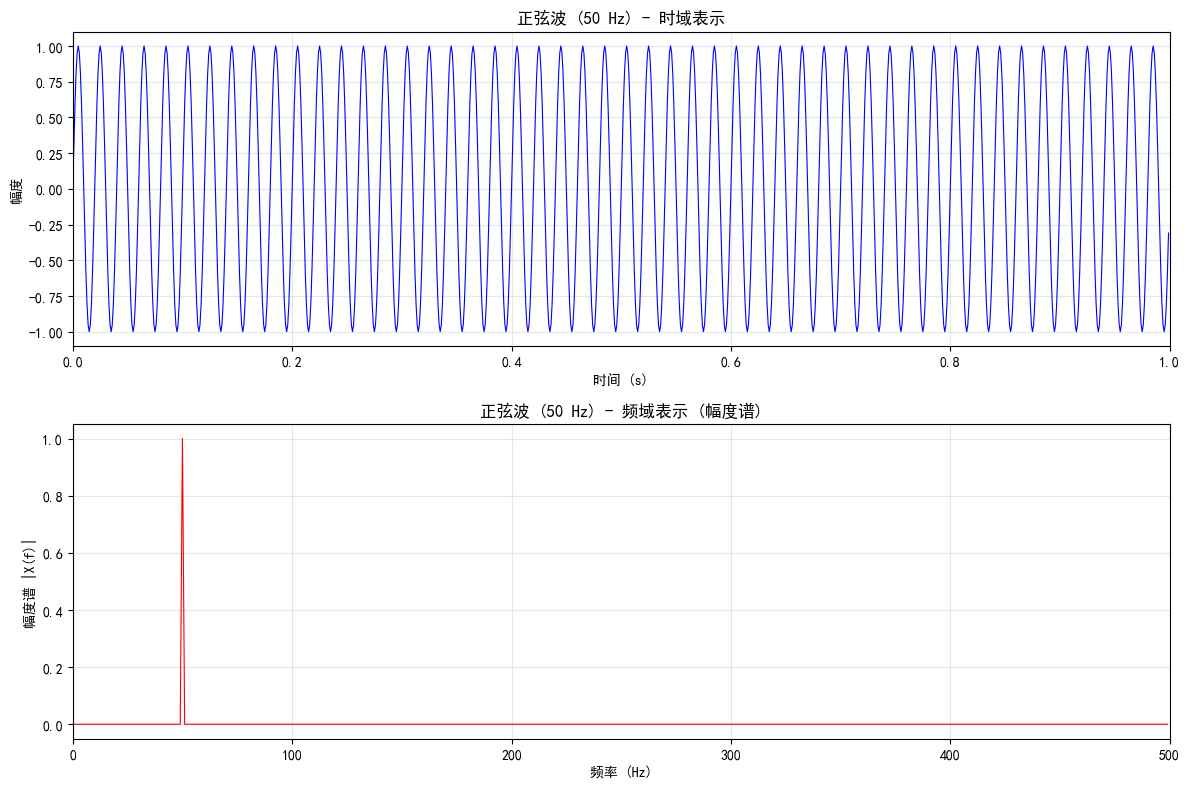

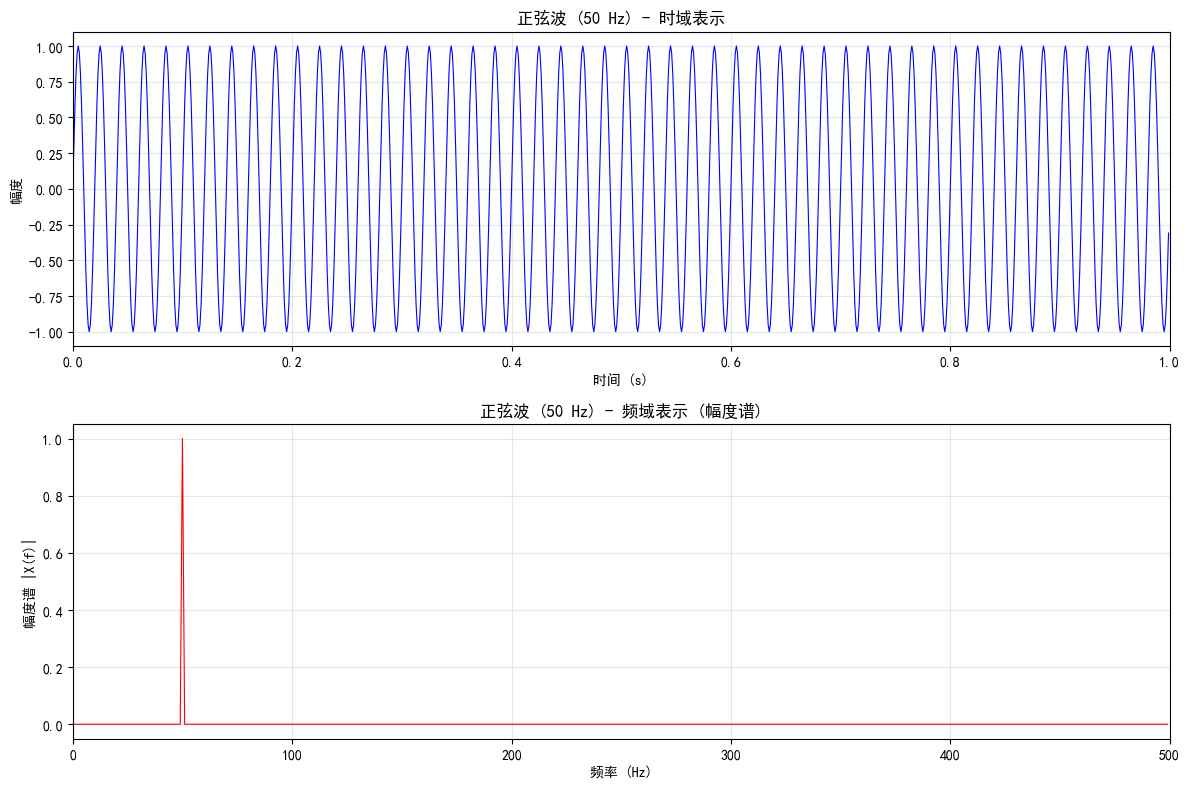

In [2]:
# Sine wave: single frequency component
f_sine = 50  # Frequency = 50 Hz
sine_wave = np.sin(2 * np.pi * f_sine * t)

plot_time_frequency(sine_wave, t, '正弦波 (50 Hz)', 1)

**观察**：正弦波在频域中表现为**两个对称的冲激**（对应正频率和负频率），表示单一频率成分。对于实信号，负频率是冗余的，实际分析时只取正频率部分。

### 3.2 方波（Square Wave）

方波包含无限多的谐波成分。

C:\Users\bigma\AppData\Local\Temp\ipykernel_35160\460879728.py:32: MatplotlibDeprecationWarning: Changing 'Figure.number' is deprecated since 3.10 and will raise an error starting 3.12
  fig.number = fig_num


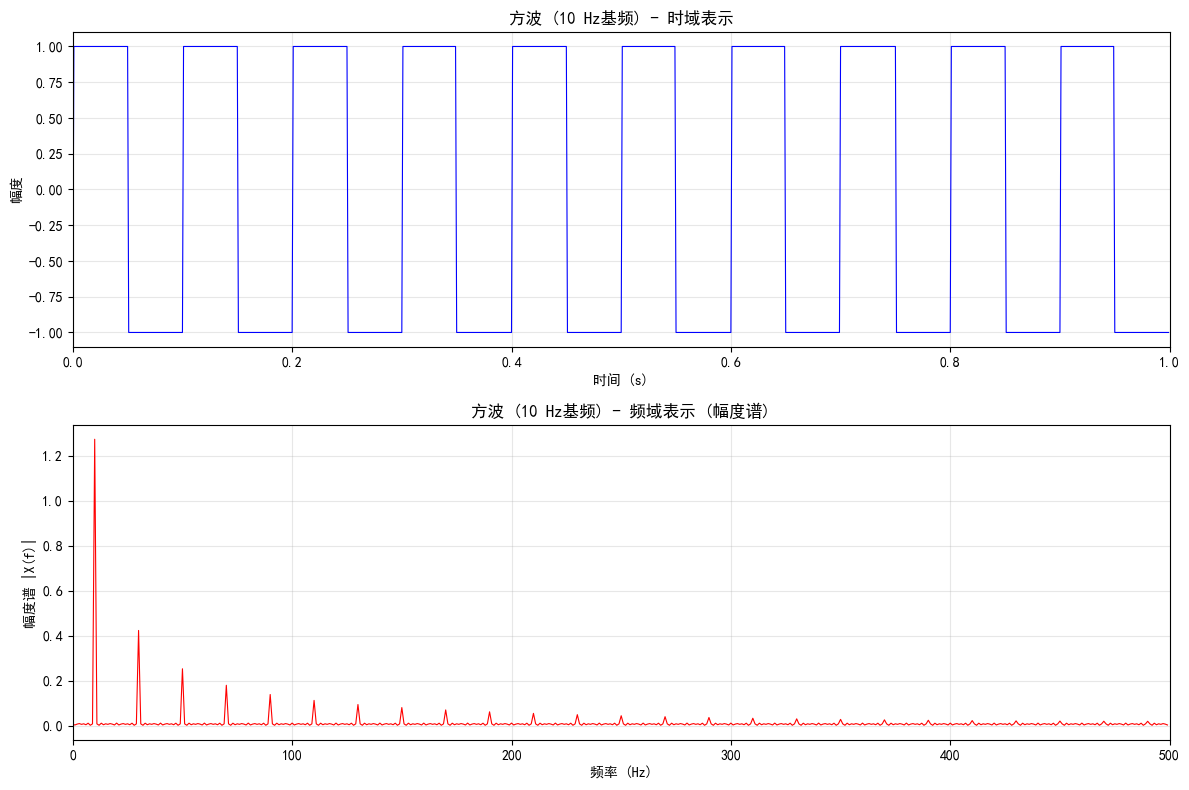

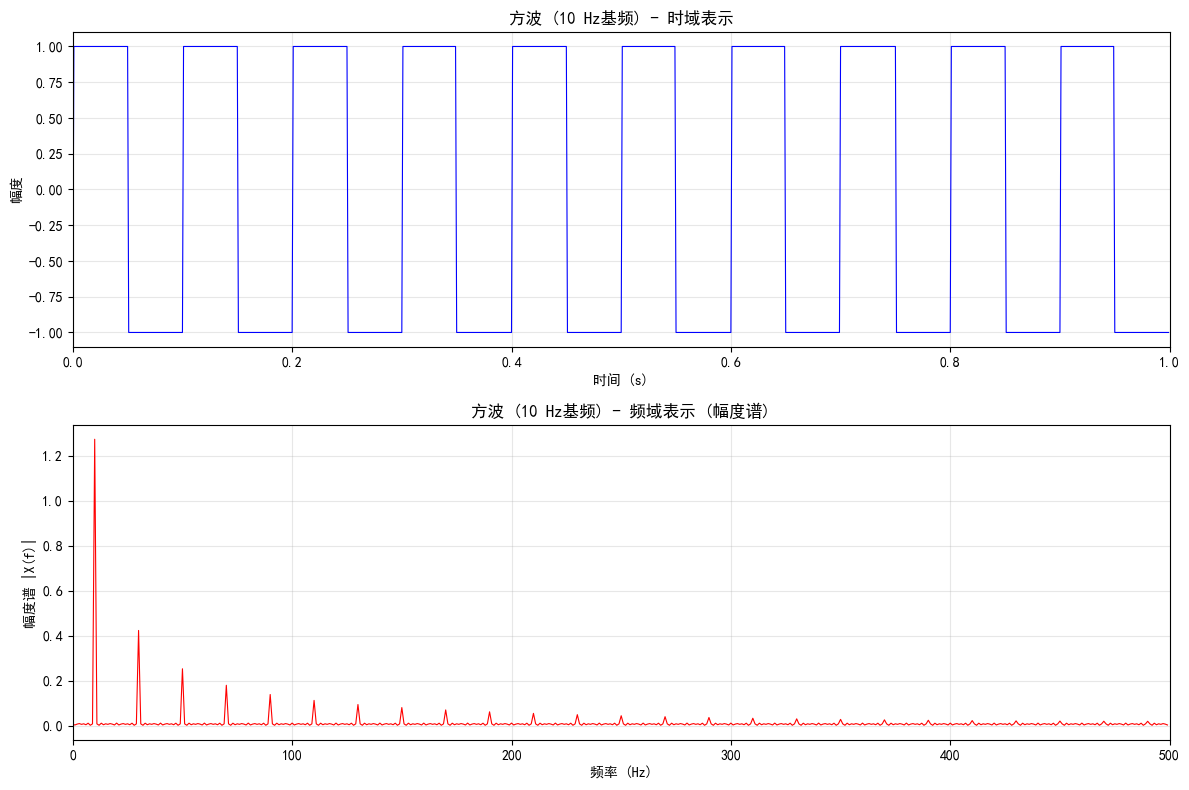

In [3]:
# Square wave: contains odd harmonics
f_square = 10  # Fundamental frequency = 10 Hz
square_wave = np.sign(np.sin(2 * np.pi * f_square * t))
# Use sign function for ideal square wave
square_wave = np.where(np.sin(2 * np.pi * f_square * t) > 0, 1.0, -1.0)

plot_time_frequency(square_wave, t, '方波 (10 Hz基频)', 2)

**观察**：方波在频域中表现为**一系列离散的频率点**，这些点对应基波的奇次谐波（1, 3, 5, 7...倍频）。理想方波有无限多谐波，但实际系统中高频成分会被衰减。

### 3.3 调幅信号（Amplitude Modulated Signal）

调幅信号是载波被低频信号调制后的结果。

C:\Users\bigma\AppData\Local\Temp\ipykernel_35160\460879728.py:32: MatplotlibDeprecationWarning: Changing 'Figure.number' is deprecated since 3.10 and will raise an error starting 3.12
  fig.number = fig_num


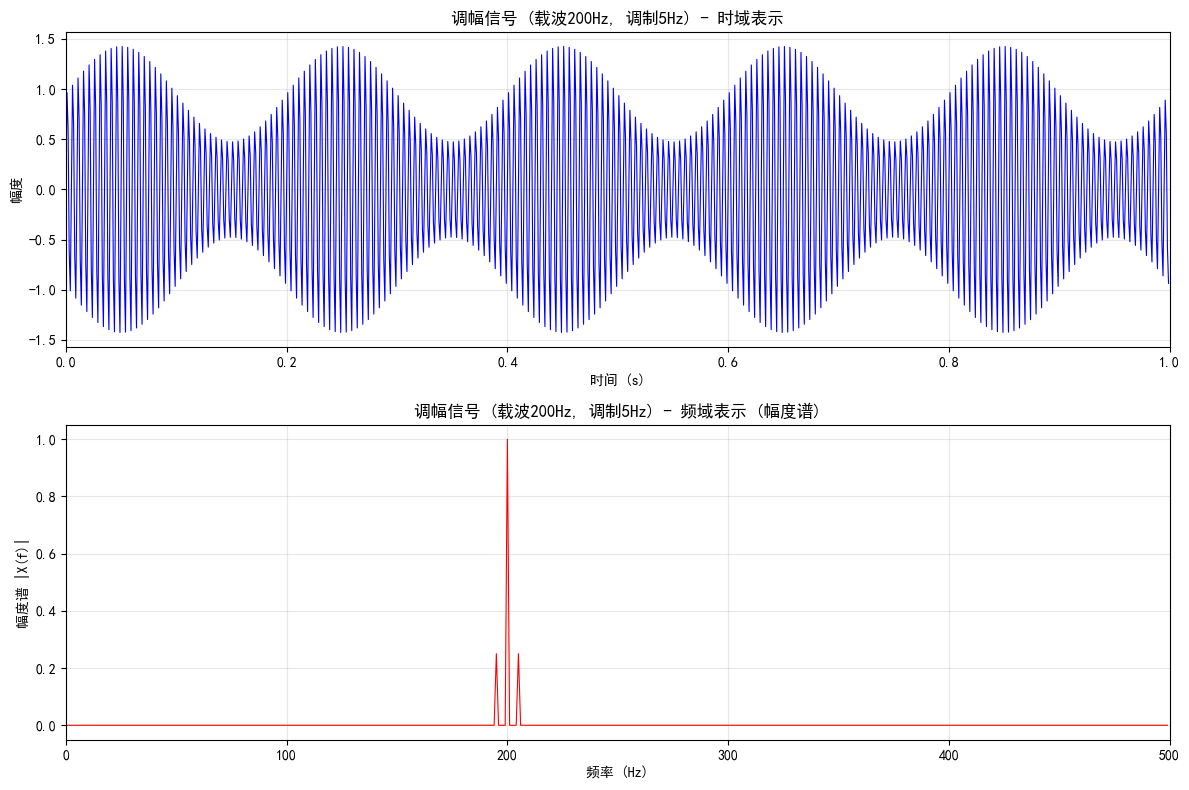

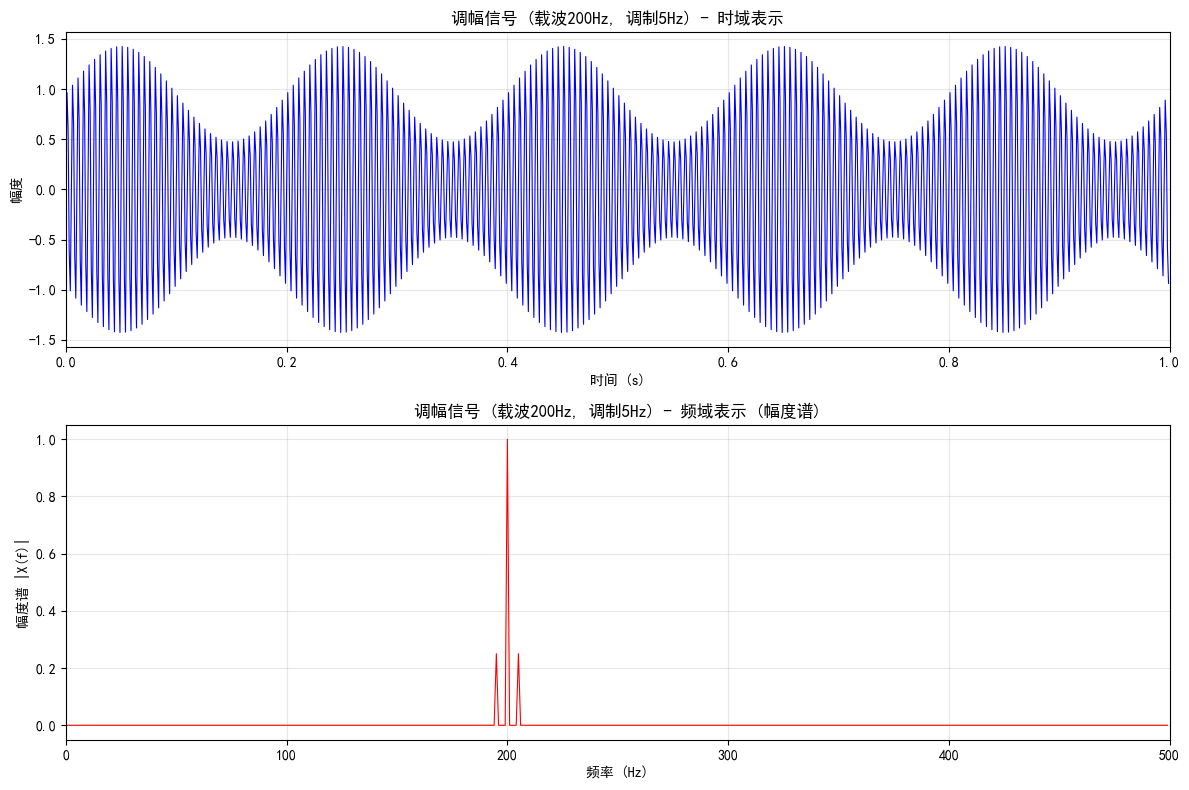

In [4]:
# Amplitude Modulated signal
# carrier frequency
f_carrier = 200  # Hz
# modulating signal (message)
f_mod = 5        # Hz
# modulated signal
am_signal = (1 + 0.5 * np.sin(2 * np.pi * f_mod * t)) * np.sin(2 * np.pi * f_carrier * t)

plot_time_frequency(am_signal, t, '调幅信号 (载波200Hz, 调制5Hz)', 3)

**观察**：调幅信号在频域中表现为**三个频率成分**——载波频率以及载波两侧的上下边带。这说明调制过程将低频信息"搬运"到了高频区域。

### 3.4 多频信号（Multi-tone Signal）

多个正弦波的叠加。

C:\Users\bigma\AppData\Local\Temp\ipykernel_35160\460879728.py:32: MatplotlibDeprecationWarning: Changing 'Figure.number' is deprecated since 3.10 and will raise an error starting 3.12
  fig.number = fig_num


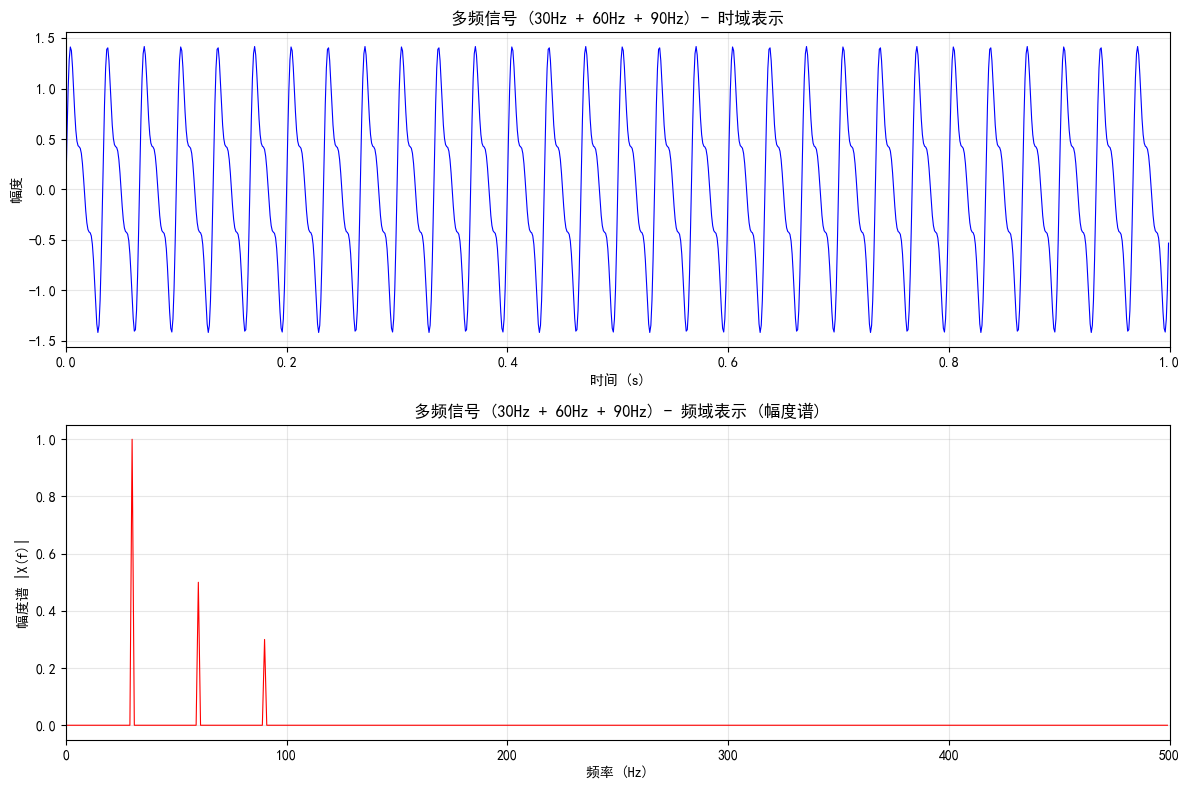

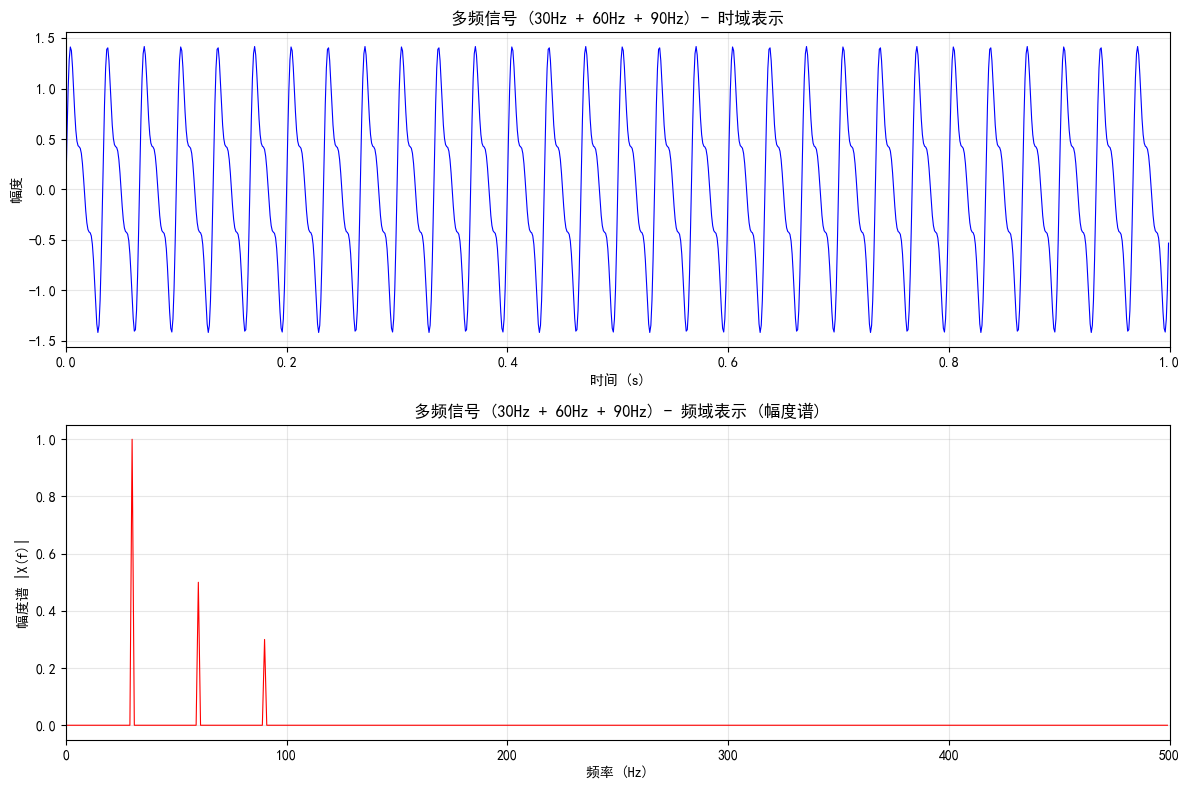

In [5]:
# Multi-tone signal: sum of multiple sinusoids
multi_tone = (np.sin(2 * np.pi * 30 * t) + 
               0.5 * np.sin(2 * np.pi * 60 * t) + 
               0.3 * np.sin(2 * np.pi * 90 * t))

plot_time_frequency(multi_tone, t, '多频信号 (30Hz + 60Hz + 90Hz)', 4)

**观察**：多频信号在频域中清晰显示各个频率成分，每个冲激的高度对应该频率分量的幅度。这展示了频域分析的核心优势——直接看出信号的频率构成。

## 4. 可视化：时频对偶性

时频对偶性可以通过以下实验直观展示：

1. **窄时域脉冲** → **宽频谱**
2. **宽时域信号** → **窄频谱**

特别地，**高斯脉冲**是唯一一个达到Heisenberg不确定性原理最小值（$\Delta t \cdot \Delta f = \frac{1}{4\pi}$）的信号。

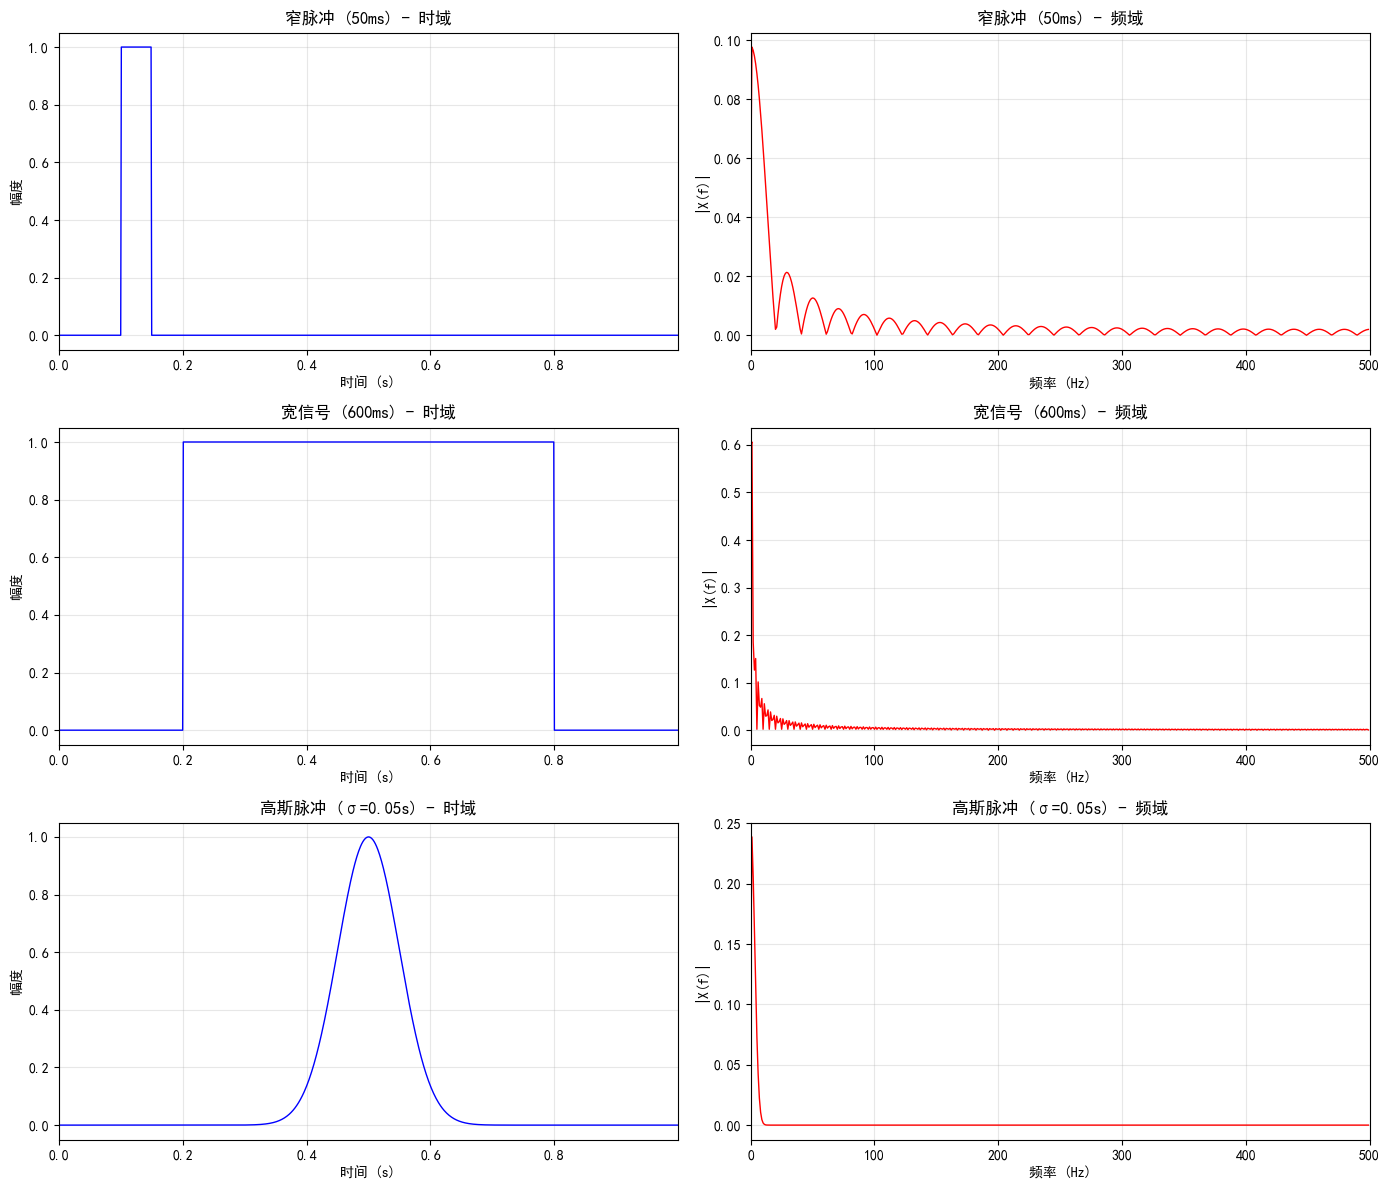

In [6]:
def compare_time_frequency_signals(t, fs, signals_dict):
    """
    Compare multiple signals showing time-frequency duality
    """
    n_signals = len(signals_dict)
    fig, axes = plt.subplots(n_signals, 2, figsize=(14, 4 * n_signals))
    
    if n_signals == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (name, signal) in enumerate(signals_dict.items()):
        # Compute FFT
        N = len(signal)
        yf = fft(signal)
        xf = fftfreq(N, 1/fs)
        
        positive_freq_idx = xf >= 0
        xf_positive = xf[positive_freq_idx]
        yf_positive = 2.0/N * np.abs(yf[positive_freq_idx])
        yf_positive[0] = yf_positive[0] / 2
        
        # Time domain
        axes[idx, 0].plot(t, signal, 'b-', linewidth=1.0)
        axes[idx, 0].set_xlabel('时间 (s)')
        axes[idx, 0].set_ylabel('幅度')
        axes[idx, 0].set_title(f'{name} - 时域')
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].set_xlim([min(t), max(t)])
        
        # Frequency domain
        axes[idx, 1].plot(xf_positive, yf_positive, 'r-', linewidth=1.0)
        axes[idx, 1].set_xlabel('频率 (Hz)')
        axes[idx, 1].set_ylabel('|X(f)|')
        axes[idx, 1].set_title(f'{name} - 频域')
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].set_xlim([0, fs/2])
        
    plt.tight_layout()
    plt.show()

# Define signals with different time-frequency characteristics
fs = 1000
T = 1.0
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Signal 1: Narrow time pulse (rectangular)
narrow_pulse = np.zeros_like(t)
narrow_pulse[(t > 0.1) & (t < 0.15)] = 1.0  # 50ms pulse

# Signal 2: Wide time signal (rectangular)
wide_signal = np.zeros_like(t)
wide_signal[(t > 0.2) & (t < 0.8)] = 1.0   # 600ms pulse

# Signal 3: Gaussian pulse (minimum uncertainty)
sigma = 0.05  # Standard deviation
gaussian_pulse = np.exp(-((t - 0.5) ** 2) / (2 * sigma ** 2))

signals_dict = {
    '窄脉冲 (50ms)': narrow_pulse,
    '宽信号 (600ms)': wide_signal,
    '高斯脉冲 (σ=0.05s)': gaussian_pulse
}

compare_time_frequency_signals(t, fs, signals_dict)

**分析**：

1. **窄脉冲**在时域中集中（50ms），在频域中展宽（主瓣宽）
2. **宽信号**在时域中分散（600ms），在频域中变窄
3. **高斯脉冲**在时域和频域都有平滑的钟形分布，且满足最小不确定性

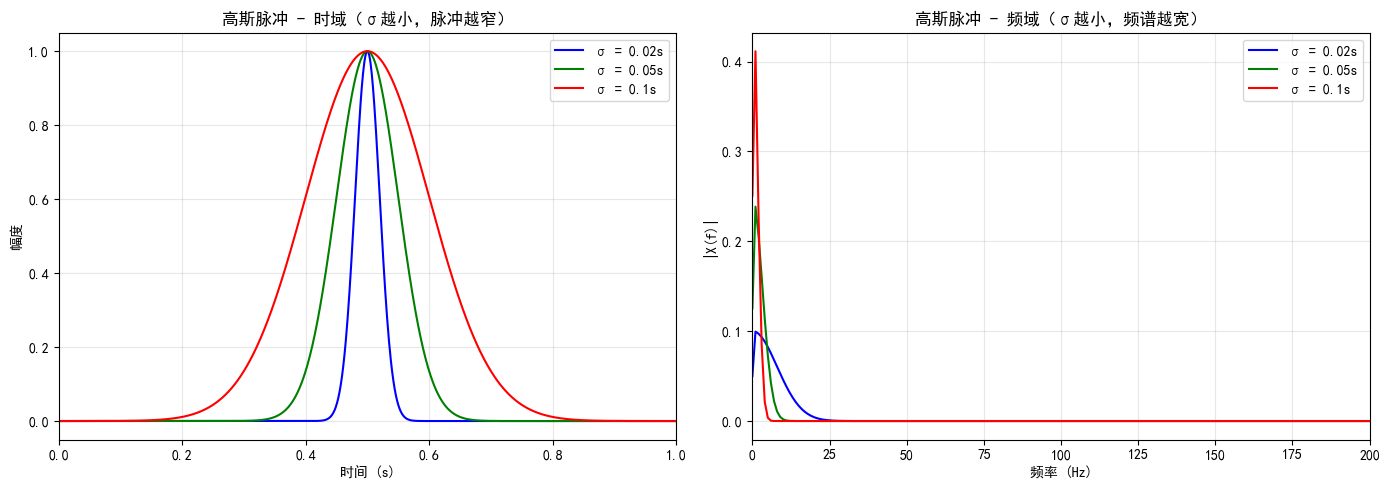

时频对偶性验证：σ越小 → 时域脉冲越窄，频域谱越宽
这证明了：窄时域信号 ↔ 宽频域信号


In [7]:
# Detailed comparison: Gaussian pulse properties
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parameters
sigma_values = [0.02, 0.05, 0.1]  # Different pulse widths
colors = ['blue', 'green', 'red']

for sigma, color in zip(sigma_values, colors):
    # Time domain
    gaussian = np.exp(-((t - 0.5) ** 2) / (2 * sigma ** 2))
    axes[0].plot(t, gaussian, color=color, linewidth=1.5, label=f'σ = {sigma}s')
    
    # Frequency domain (analytical: Gaussian in time -> Gaussian in frequency)
    N = len(t)
    yf = fft(gaussian)
    xf = fftfreq(N, 1/fs)
    positive_freq_idx = xf >= 0
    xf_positive = xf[positive_freq_idx]
    yf_positive = 2.0/N * np.abs(yf[positive_freq_idx])
    yf_positive[0] = yf_positive[0] / 2
    
    axes[1].plot(xf_positive, yf_positive, color=color, linewidth=1.5, label=f'σ = {sigma}s')

axes[0].set_xlabel('时间 (s)')
axes[0].set_ylabel('幅度')
axes[0].set_title('高斯脉冲 - 时域（σ越小，脉冲越窄）')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])

axes[1].set_xlabel('频率 (Hz)')
axes[1].set_ylabel('|X(f)|')
axes[1].set_title('高斯脉冲 - 频域（σ越小，频谱越宽）')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 200])

plt.tight_layout()
plt.show()

print("时频对偶性验证：σ越小 → 时域脉冲越窄，频域谱越宽")
print("这证明了：窄时域信号 ↔ 宽频域信号")

## 5. 短时傅里叶变换（STFT）简介

STFT是时域和频域分析的折中方案。

**核心思想**：
- 使用滑动窗口将信号分段
- 对每段信号进行傅里叶变换
- 得到随时间变化的频谱（时频图）

**数学表达**：
$$X(t, f) = \int_{-\infty}^{\infty} x(\tau) w(\tau - t) e^{-j2\pi f \tau} d\tau$$

其中 $w(t)$ 是窗函数。

In [8]:
from scipy.signal import stft
import matplotlib.pyplot as plt

def plot_stft(signal, t, fs, nperseg, title, figsize=(12, 8)):
    """
    Compute and plot STFT
    """
    # Compute STFT
    f, t_stft, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=nperseg//2)
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    
    # Time domain signal
    axes[0].plot(t, signal, 'b-', linewidth=0.8)
    axes[0].set_xlabel('时间 (s)')
    axes[0].set_ylabel('幅度')
    axes[0].set_title(f'{title} - 时域信号')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([t[0], t[-1]])
    
    # STFT spectrogram (magnitude)
    im = axes[1].pcolormesh(t_stft, f, np.abs(Zxx), shading='gouraud', cmap='viridis')
    axes[1].set_ylabel('频率 (Hz)')
    axes[1].set_xlabel('时间 (s)')
    axes[1].set_title(f'STFT 频谱图 (窗口长度 = {nperseg} 点)')
    axes[1].set_ylim([0, fs/2])
    plt.colorbar(im, ax=axes[1], label='幅度 |X(t,f)|')
    
    plt.tight_layout()
    plt.show()
    
    return f, t_stft, Zxx

### 5.1 线性调频信号（Chirp Signal）的STFT分析

Chirp信号的频率随时间线性变化。

STFT 分析：观察窗口大小对时频分辨率的影响

窗口长度 = 64 点（时间分辨率高，频率分辨率低）


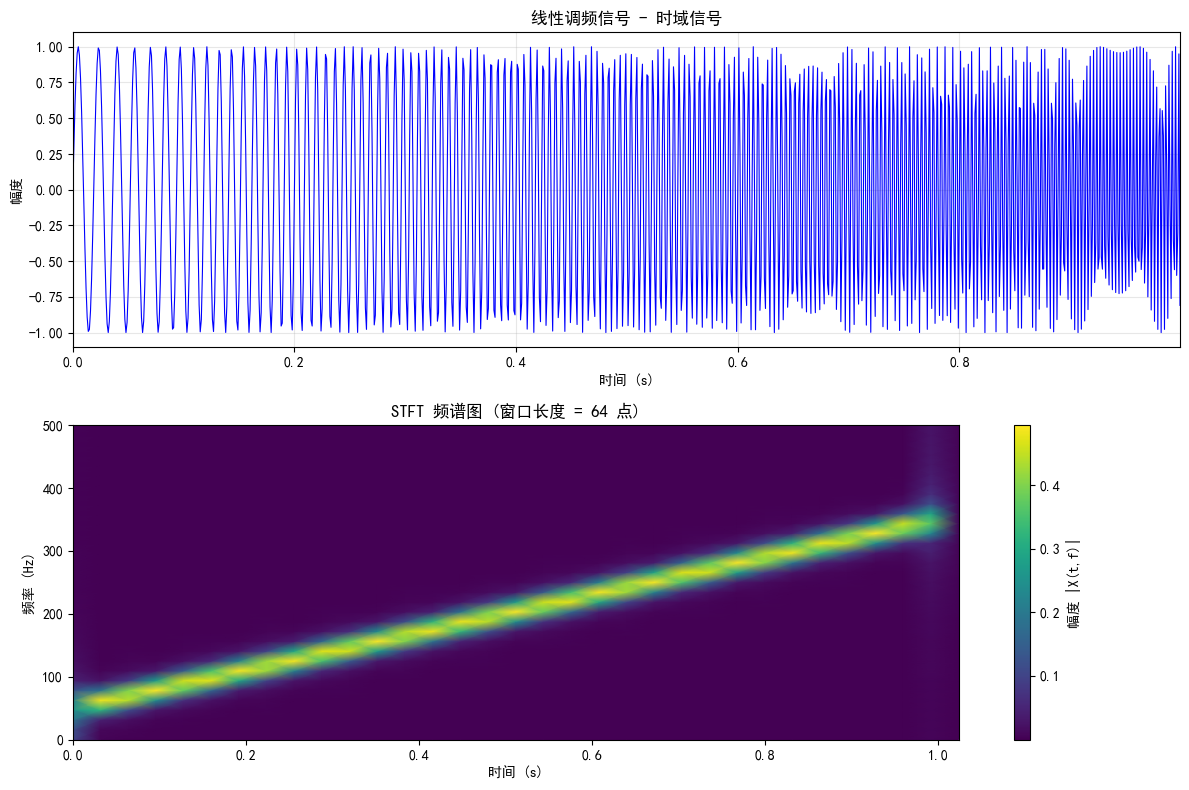

In [9]:
# Chirp signal: frequency increases linearly with time
fs = 1000
T = 1.0
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Chirp from 50 Hz to 200 Hz
chirp_signal = np.sin(2 * np.pi * (50 + 150 * t) * t)

# Plot STFT with different window sizes
print("STFT 分析：观察窗口大小对时频分辨率的影响\n")

# Small window: good time resolution, poor frequency resolution
print("窗口长度 = 64 点（时间分辨率高，频率分辨率低）")
f1, t1, Z1 = plot_stft(chirp_signal, t, fs, nperseg=64, title='线性调频信号')

窗口长度 = 256 点（时间分辨率低，频率分辨率高）


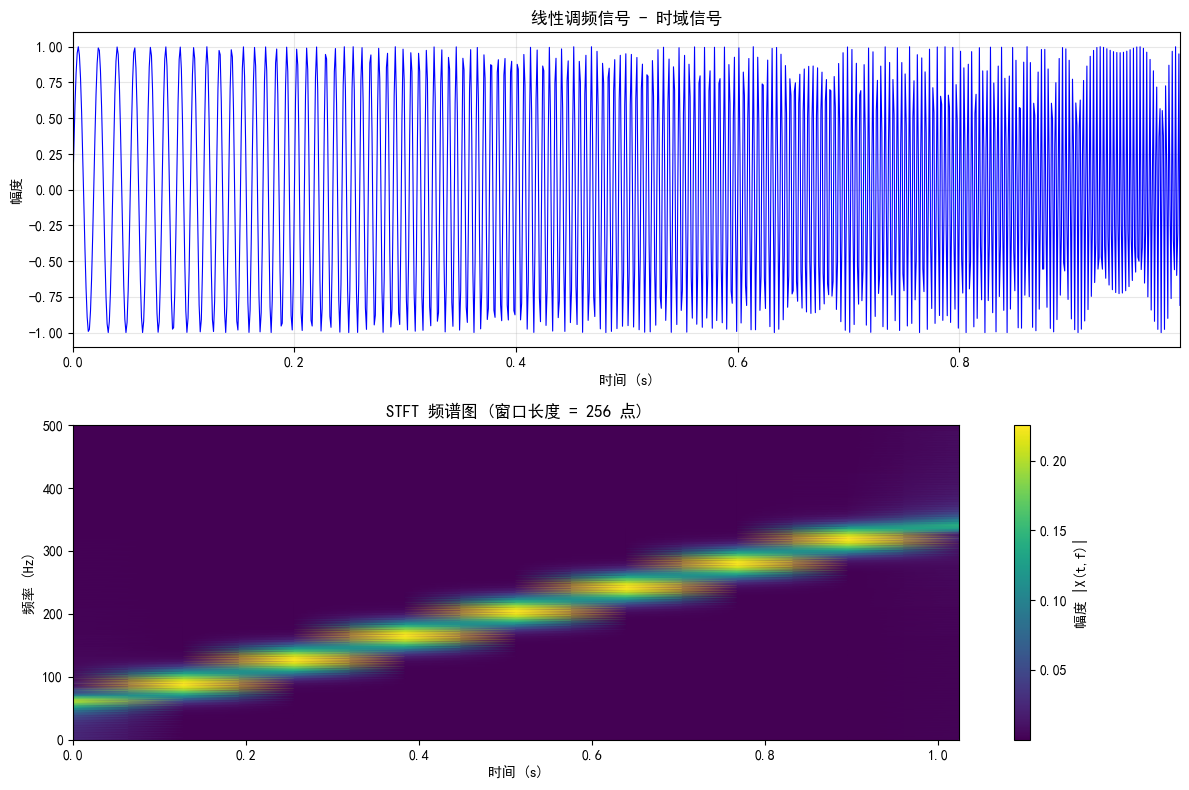

In [10]:
# Large window: poor time resolution, good frequency resolution
print("窗口长度 = 256 点（时间分辨率低，频率分辨率高）")
f2, t2, Z2 = plot_stft(chirp_signal, t, fs, nperseg=256, title='线性调频信号')

**观察**：

- **小窗口（64点）**：时间分辨率高，能清晰看到频率随时间变化的路径，但频率分辨率低，谱线较粗
- **大窗口（256点）**：频率分辨率高，能准确确定各时刻的频率值，但时间分辨率低，频率变化轨迹模糊

这正是Heisenberg不确定性原理在实践中的体现：**窗口大小决定了时频分辨率的tradeoff**。

### 5.2 非平稳信号示例：多分量信号

展示STFT如何处理频率成分随时间变化的信号。

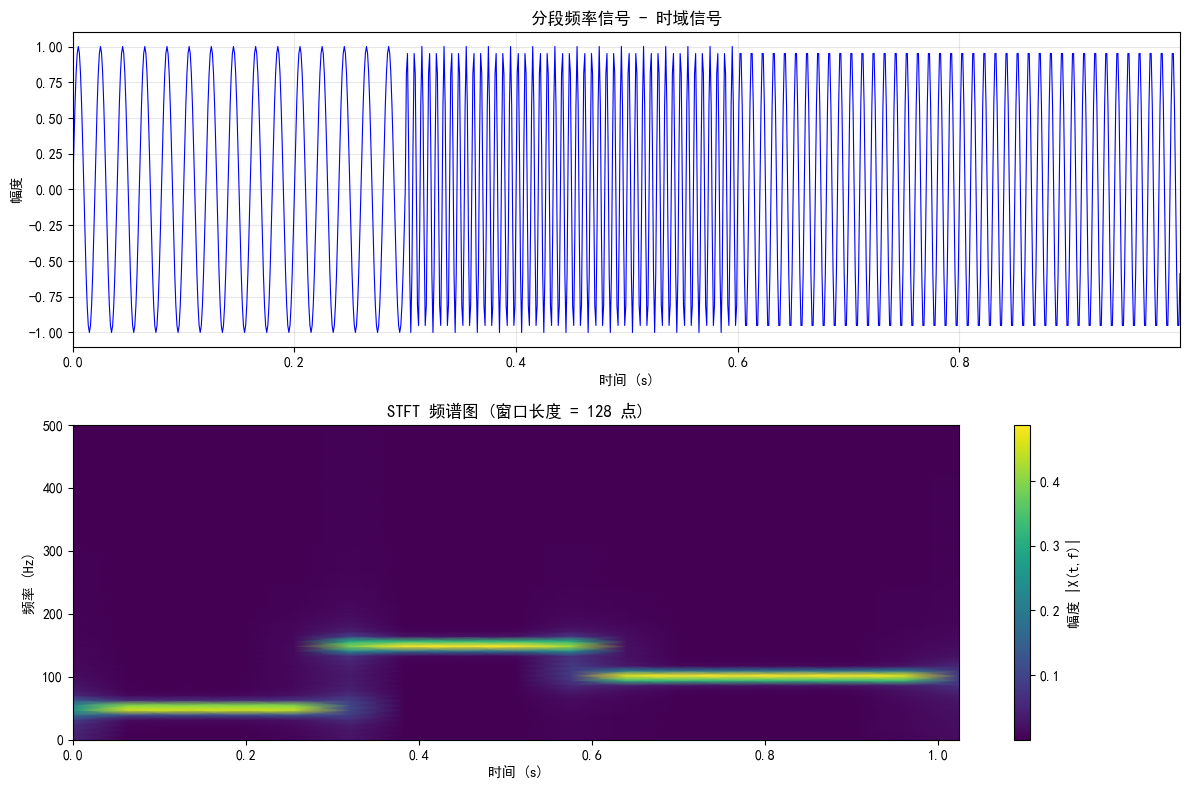

In [11]:
# Non-stationary signal: frequency changes at different time intervals
fs = 1000
T = 1.0
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Create signal with different frequencies in different time intervals
piecewise_signal = np.zeros_like(t)
# 0-0.3s: 50 Hz
mask1 = (t >= 0) & (t < 0.3)
piecewise_signal[mask1] = np.sin(2 * np.pi * 50 * t[mask1])
# 0.3-0.6s: 150 Hz
mask2 = (t >= 0.3) & (t < 0.6)
piecewise_signal[mask2] = np.sin(2 * np.pi * 150 * t[mask2])
# 0.6-1.0s: 100 Hz
mask3 = (t >= 0.6) & (t <= 1.0)
piecewise_signal[mask3] = np.sin(2 * np.pi * 100 * t[mask3])

# Plot STFT
f, t_stft, Zxx = plot_stft(piecewise_signal, t, fs, nperseg=128, title='分段频率信号')

**观察**：STFT的频谱图清晰显示了三个时间区间各自的频率成分：

- 0-0.3s：50 Hz
- 0.3-0.6s：150 Hz
- 0.6-1.0s：100 Hz

这说明STFT能够**同时定位信号的时间和频率成分**，是分析非平稳信号的有力工具。

## 6. 关联OTFS

OTFS（正交时频空，Orthogonal Time Frequency Space）是一种新兴的调制技术，与传统的OFDM相比具有独特的优势。

### 6.1 OFDM与时频域

**OFDM（正交频分复用）** 是当前4G/5G系统广泛使用的调制方式：

- 在**时频域**进行信号处理
- 将可用带宽分成多个正交子载波
- 每个符号在特定时间slot和子载波上传输
- 使用FFT/IFFT实现高效的调制解调

**时频域表示的问题**：
- 在高速移动场景下，多径效应导致信道时变
- 时间和频率的相互影响使得信道估计复杂化
- 散射丰富的环境中，时频域表示不够稀疏

### 6.2 OTFS与延迟-多普勒域

**OTFS** 采用了完全不同的方法：

1. **首先将时频域信号变换到延迟-多普勒域（Delay-Doppler Domain）**
2. 在延迟-多普勒域进行信道建模和信号处理
3. 最后再转换回时频域进行传输

**延迟-多普勒域的优势**：
- 物理信道在延迟-多普勒域具有**稀疏表示**
- 多径效应 → 延迟分量
- 移动性 → 多普勒偏移
- 信道结构不随时间变化（准静态）
- 适合高移动性、高散射的场景

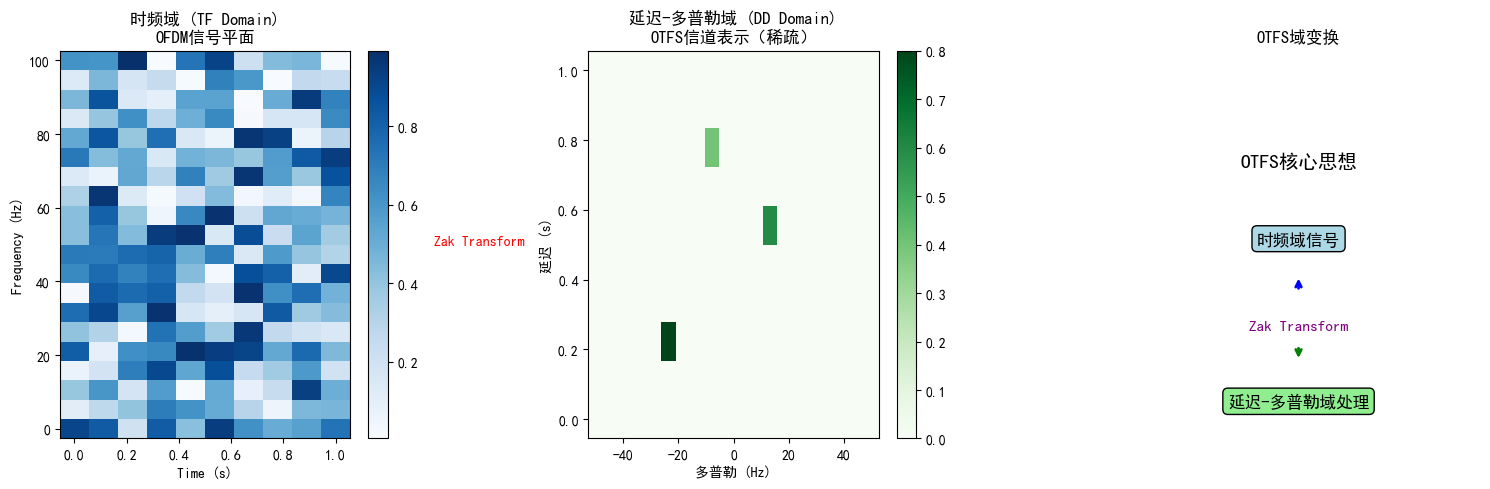

OTFS关键点：
1. OFDM在时频域（Time-Frequency）工作
2. OTFS先通过Zak Transform转换到延迟-多普勒域
3. 在DD域中信道呈现稀疏结构
4. 这种表示特别适合高移动性场景


In [12]:
# Visualize the OTFS domain transformation concept
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Time-Frequency Domain representation
# Grid of time slots vs frequency subcarriers
tf_time = np.linspace(0, 1, 10)  # Time slots
tf_freq = np.linspace(0, 100, 20)  # Subcarriers (frequency)
T, F = np.meshgrid(tf_time, tf_freq)

im1 = axes[0].pcolormesh(T, F, np.random.rand(20, 10), cmap='Blues', shading='auto')
axes[0].set_xlabel('时间 (s)')
axes[0].set_ylabel('频率 (Hz)')
axes[0].set_title('时频域 (TF Domain)\nOFDM信号平面')
plt.colorbar(im1, ax=axes[0])
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Frequency (Hz)')

# Arrow between TF and DD
axes[0].annotate('', xy=(1.3, 50), xytext=(1.1, 50),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[0].text(1.35, 50, ' Zak Transform', fontsize=10, color='red')

# Delay-Doppler Domain representation
dd_delay = np.linspace(0, 1, 10)  # Delay
dd_doppler = np.linspace(-50, 50, 20)  # Doppler
D, L = np.meshgrid(dd_doppler, dd_delay)

# Sparse representation (typical OTFS channel)
sparse_signal = np.zeros((10, 20))
sparse_signal[2, 5] = 0.8  # Path 1
sparse_signal[5, 12] = 0.6  # Path 2
sparse_signal[7, 8] = 0.4  # Path 3

im2 = axes[1].pcolormesh(D, L, sparse_signal, cmap='Greens', shading='auto')
axes[1].set_xlabel('多普勒 (Hz)')
axes[1].set_ylabel('延迟 (s)')
axes[1].set_title('延迟-多普勒域 (DD Domain)\nOTFS信道表示（稀疏）')
plt.colorbar(im2, ax=axes[1])

# Show the transformation concept
axes[2].text(0.5, 0.7, 'OTFS核心思想', fontsize=14, fontweight='bold', 
             ha='center', transform=axes[2].transAxes)
axes[2].text(0.5, 0.5, '时频域信号', fontsize=12, ha='center', transform=axes[2].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightblue'))
axes[2].annotate('', xy=(0.5, 0.42), xytext=(0.5, 0.38),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2))
axes[2].text(0.5, 0.28, 'Zak Transform', fontsize=11, ha='center', transform=axes[2].transAxes,
             color='purple')
axes[2].annotate('', xy=(0.5, 0.20), xytext=(0.5, 0.24),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[2].text(0.5, 0.08, '延迟-多普勒域处理', fontsize=12, ha='center', transform=axes[2].transAxes,
             bbox=dict(boxstyle='round', facecolor='lightgreen'))
axes[2].axis('off')
axes[2].set_title('OTFS域变换')

plt.tight_layout()
plt.show()

print("OTFS关键点：")
print("1. OFDM在时频域（Time-Frequency）工作")
print("2. OTFS先通过Zak Transform转换到延迟-多普勒域")
print("3. 在DD域中信道呈现稀疏结构")
print("4. 这种表示特别适合高移动性场景")

### 6.3 域变换基础

理解OTFS需要掌握三种主要的域变换：

| 变换 | 从 → 到 | 应用 |
|------|---------|------|
| 傅里叶变换 (FT) | 时间 ↔ 频率 | 基础频谱分析 |
| 短时傅里叶变换 (STFT) | 时间 → 时频 | 非平稳信号分析 |
| Zak Transform | 时频 ↔ 延迟-多普勒 | OTFS调制核心 |

**OTFS的完整流程**：
1. 信息比特 → QAM符号
2. QAM符号 → 放置到延迟-多普勒格点（DD域）
3. Zak逆变换 → 时频域信号
4. OFDM调制 → 射频信号

**接收端反向操作**：
1. OFDM解调 → 时频域信号
2. Zak变换 → 延迟-多普勒域
3. 均衡/检测 → 恢复QAM符号
4. QAM → 信息比特

## 7. 思考题

1. **对偶性验证**：如果一个信号在时域是有限长度的矩形脉冲，它的频谱有什么特点？为什么？

2. **不确定性原理**：解释为什么在设计雷达或通信系统时，不能同时追求无限好的时间分辨率和频率分辨率。给出一个实际的tradeoff例子。

3. **STFT窗口选择**：假设你要分析一个 chirp 信号（频率随时间线性增长），讨论：
   - 如果选择非常小的STFT窗口（如16点），会发生什么？
   - 如果选择非常大的STFT窗口（如1024点），会发生什么？
   - 如何选择合适的窗口大小？

4. **OTFS优势**：在什么场景下OTFS比传统OFDM更有优势？为什么延迟-多普勒域的稀疏性在这些场景中很重要？

5. **实际应用**：考虑一个高速列车通信场景，列车速度300 km/h，载波频率2 GHz。请分析：
   - 这种情况下信道有什么特点？
   - OFDM可能面临什么挑战？
   - OTFS如何解决这些挑战？

---

**参考资源**：

- Oppenheim, A. V., & Willsky, A. S. (1997). *Signals and Systems*
- Hadani, R., & Monk, A. (2012). OTFS: A New Modulation Scheme for Future Wireless Systems
- 本notebook是OTFS学习教程的一部分